<a href="https://colab.research.google.com/github/Ankit-Saha08/iit-kgp-genai-lab-notebooks/blob/main/Classification_task_tutorial_FINAL_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Tutorial

### How to use this notebook
- You can run this notebook in **Google Colab** or **Kaggle Notebooks**.
- A **code cell** contains Python instructions. Run it with the play button or **Shift + Enter**.
- Cells share the same Python session, so variables created earlier can be used later.
- In the code below, explanatory comments beginning with `# ↳` tell you **exactly what the next line is doing and why**.
- The non-DIY section is fully worked. The DIY sections remain intentionally incomplete so learners can implement them themselves.

### Main story
**Patient measurements → features `X` → labels `y` → train/test split → scaling → Logistic Regression → predictions → evaluation**

> Teaching note: this is a machine-learning demonstration using the Breast Cancer Wisconsin dataset. It is not a clinical diagnostic system.


# Breast Cancer Prediction using scikit-learn #

![breast cancer detection image](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-024-57740-5/MediaObjects/41598_2024_57740_Fig1_HTML.png)

Problem - Breast cancer prediction is a binary classification problem where the goal is to determine whether a tumor is malignant (cancerous) or benign (non-cancerous) based on measurable characteristics of cell nuclei obtained from medical imaging or biopsies.


## Import required libraries ##

In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We import the Python libraries and scikit-learn tools needed later.
# Nothing is trained in this cell. We are only bringing useful tools
# into the notebook so that later cells can call them.
# ================================================================

# ↳ Import NumPy and give it the short name np.
# NumPy provides arrays and numerical operations used throughout machine learning.
import numpy as np

# ↳ Import Matplotlib's plotting interface and call it plt.
# This gives us plotting tools if we want to visualise data or model behaviour.
import matplotlib.pyplot as plt

# ↳ Import scikit-learn's built-in Breast Cancer Wisconsin dataset loader.
# Calling load_breast_cancer() later will give us the features, labels and metadata.
from sklearn.datasets import load_breast_cancer

# ↳ Import the helper that divides a dataset into training and test portions.
# We need unseen test examples so that we can measure generalisation.
from sklearn.model_selection import train_test_split

# ↳ Import StandardScaler.
# StandardScaler rescales each feature using the training-set mean and standard deviation.
from sklearn.preprocessing import StandardScaler


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================


## Loading the breast cancer data ##

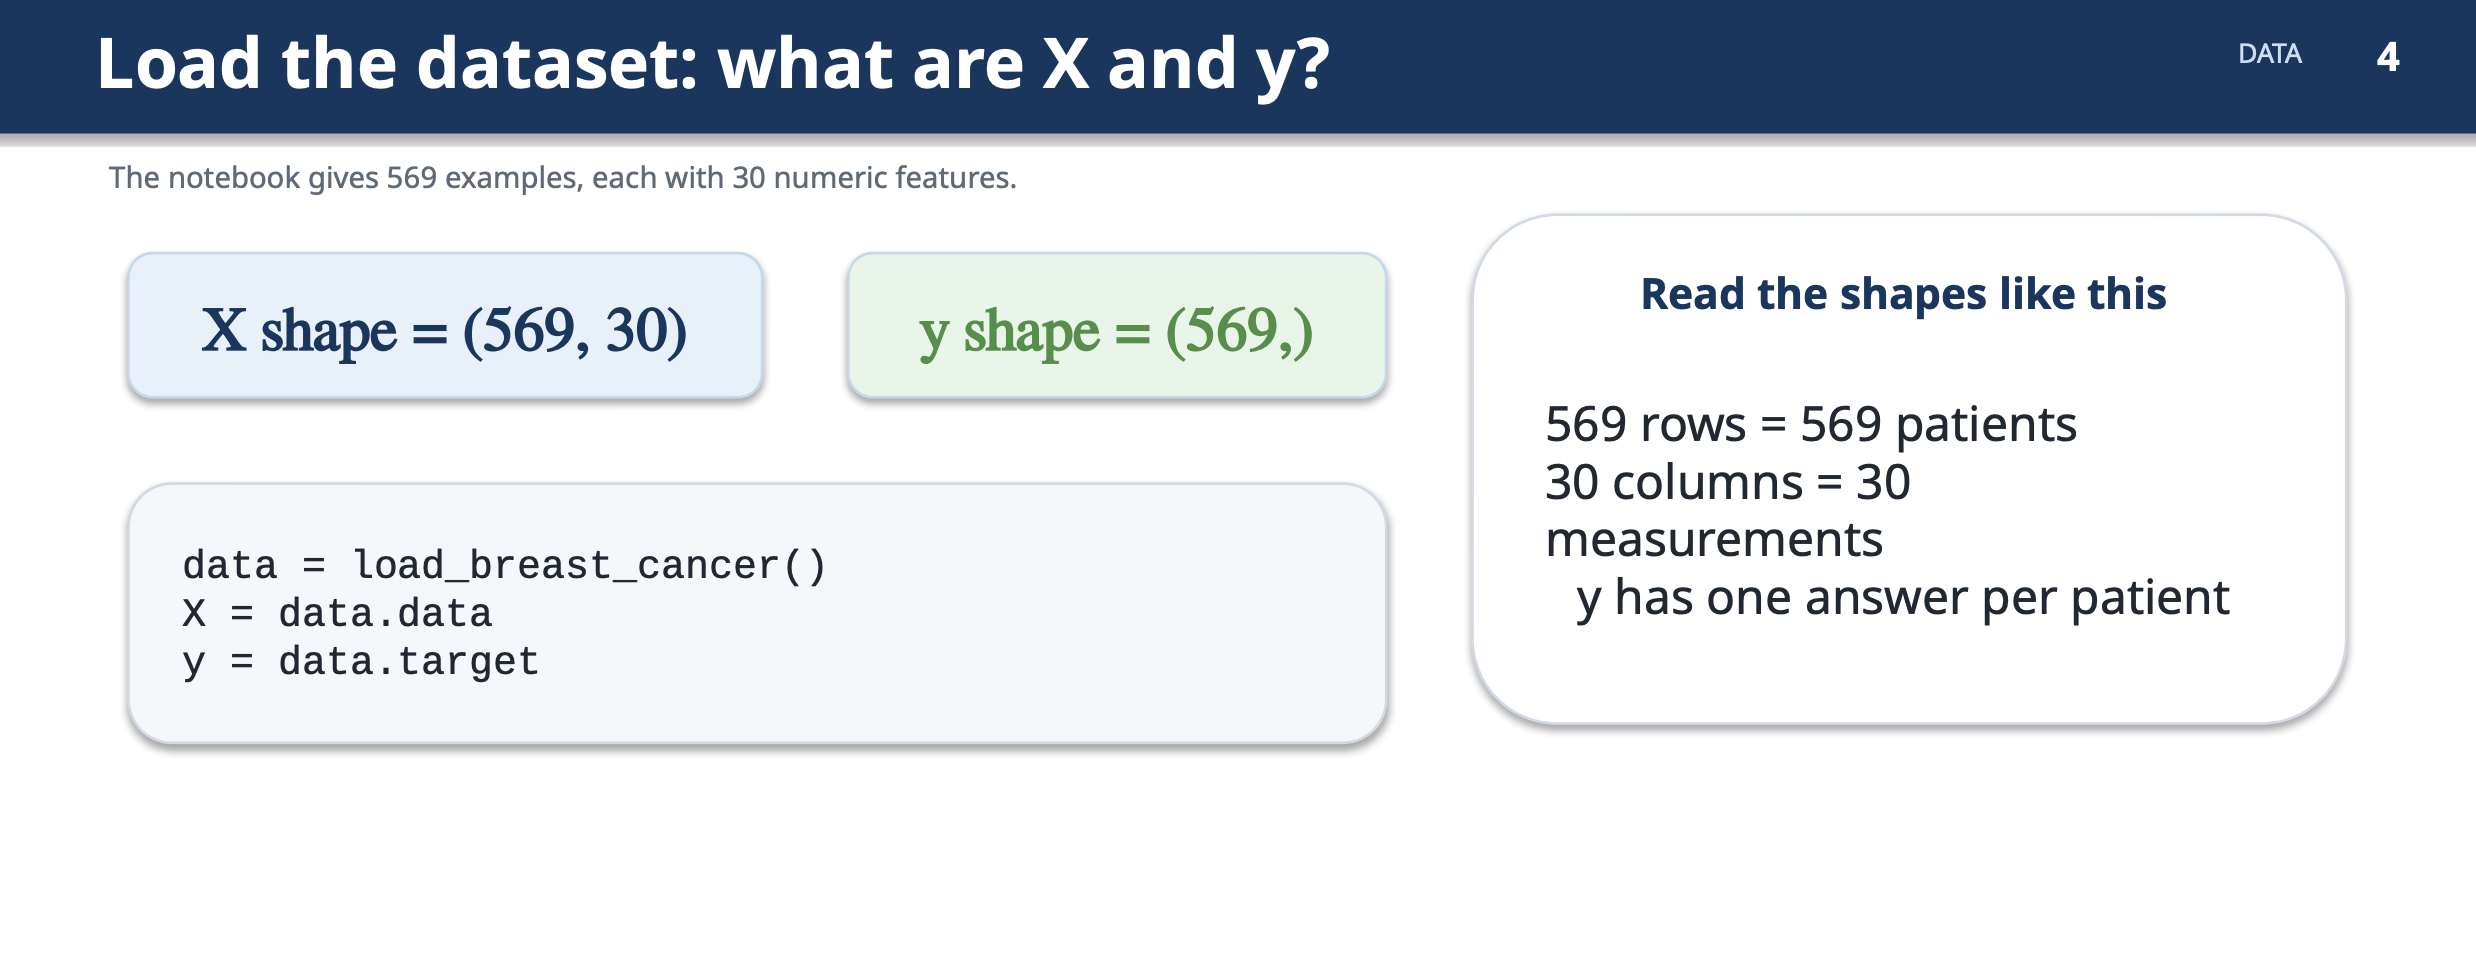



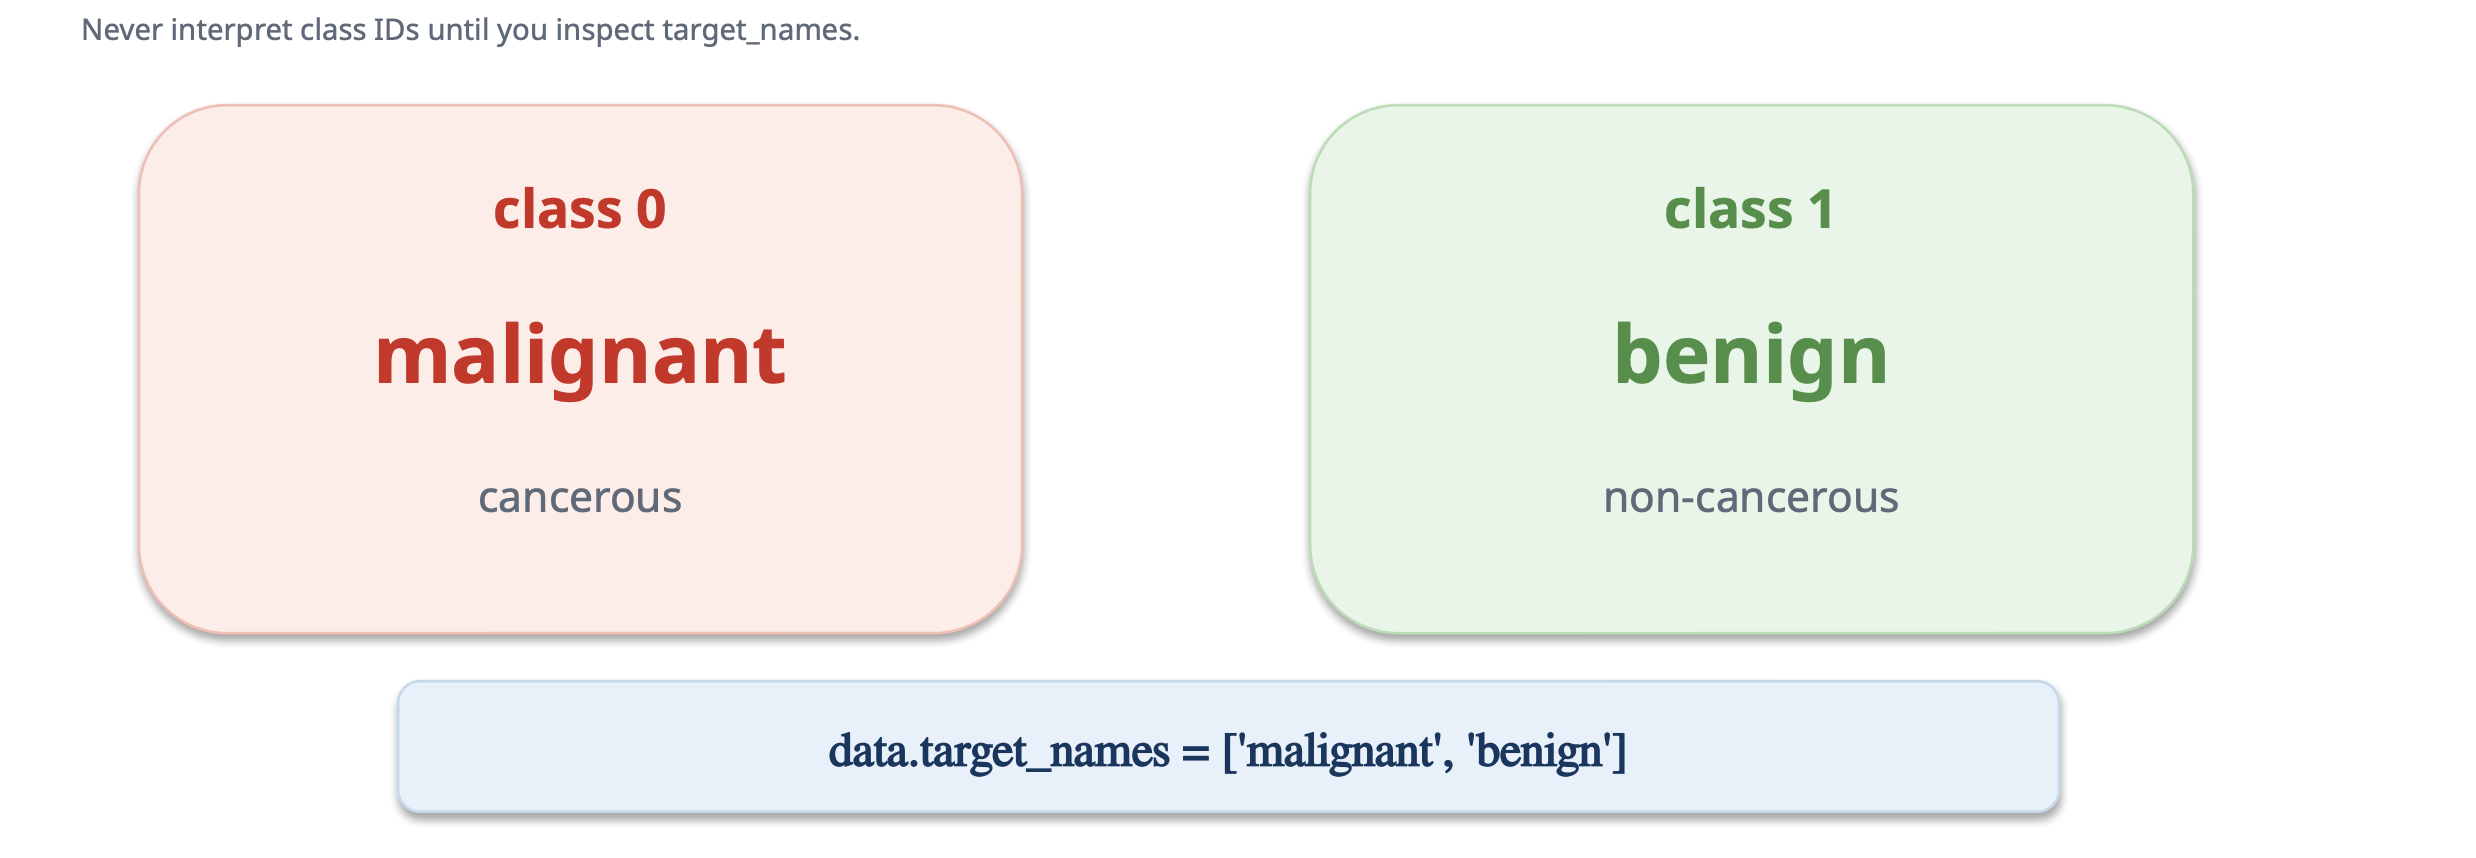

In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We load the breast-cancer dataset and separate it into:
#   X = the input measurements/features
#   y = the correct class labels/answers
#
# For this dataset:
#   X has 569 rows (patients) and 30 columns (measurements).
#   y has one label for each patient.
# ================================================================

# ↳ Load the complete Breast Cancer Wisconsin dataset object.
# The returned object contains data, target labels, feature names and metadata.
data = load_breast_cancer()

# ↳ Extract the input feature matrix from the dataset.
# X[i] contains the 30 numerical measurements for patient i.
X = data.data

# ↳ Extract the target labels.
# In this dataset: 0 = malignant and 1 = benign.
y = data.target

# ↳ Print the shape of X so we can verify how many examples and features we have.
# Expected meaning: (569, 30) = 569 patients × 30 features.
print("Shape:", X.shape)


Shape: (569, 30)


In [ ]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We inspect the shape of the target array y.
# There should be exactly one answer/label for every row in X.
# ================================================================

# ↳ Print y.shape.
# (569,) means y is a one-dimensional array containing 569 class labels.
print("Shape:", y.shape)


Shape: (569,)


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We check what the numeric labels 0 and 1 actually mean.
# Never assume that 0 means "negative" or 1 means "positive";
# class IDs only get meaning from the dataset definition.
# ================================================================

# ↳ Print the class-name lookup supplied with the dataset.
# Output: ['malignant' 'benign'], so class 0 = malignant and class 1 = benign.
print(data.target_names)


['malignant' 'benign']


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We display the complete scikit-learn dataset object.
# This lets us inspect its data matrix, labels, feature names and description.
# ================================================================

# ↳ In a notebook, writing a variable name as the final expression displays its representation.
# This is for inspection only; it does not modify the dataset.
data


{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

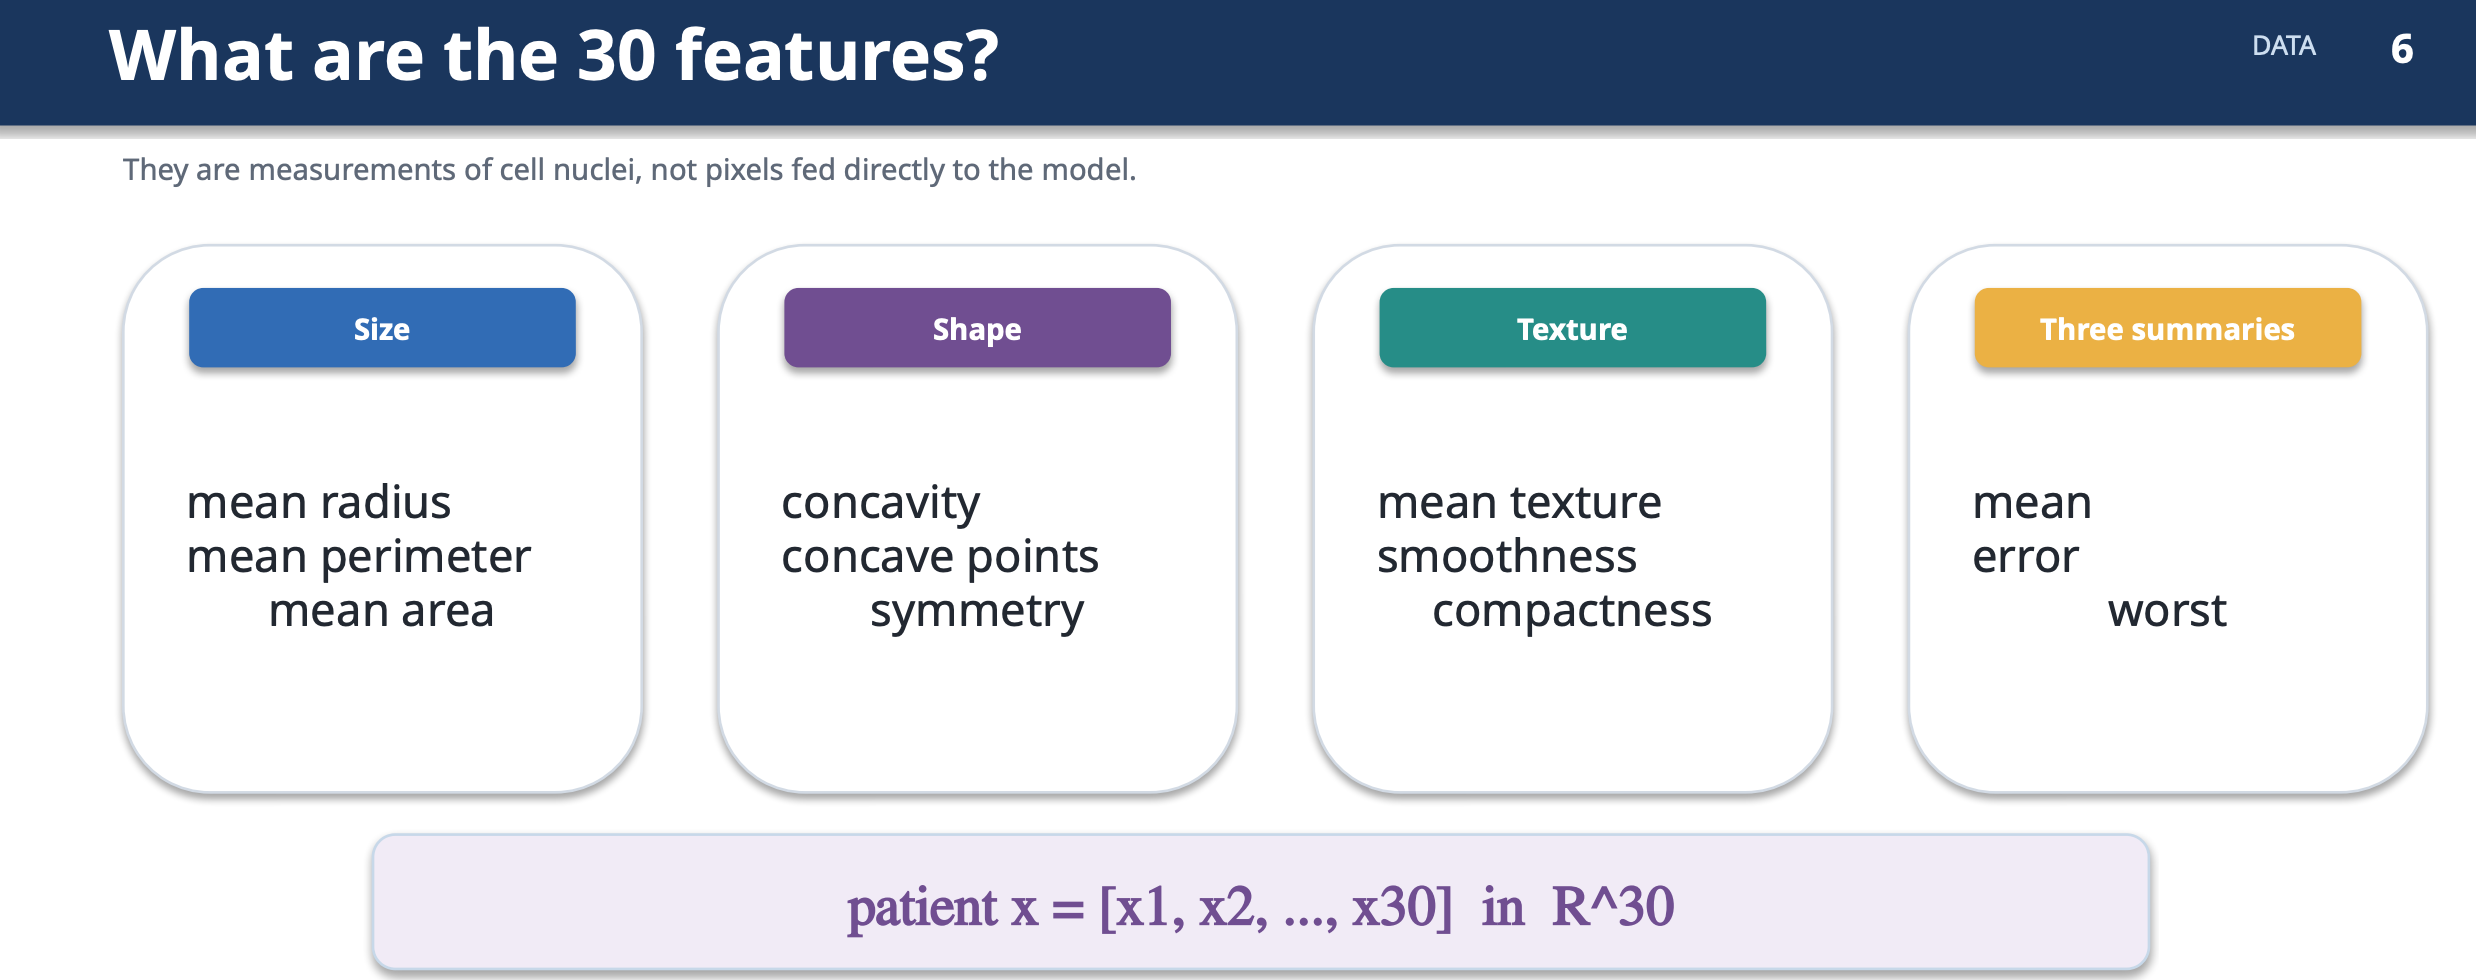

In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We inspect the names of the 30 input features.
# Each patient is represented numerically by these measurements.
# Examples include radius, texture, perimeter, area and concavity.
# ================================================================

# ↳ Print the ordered list of feature names.
# Column j of X corresponds to feature_names[j].
print(data.feature_names)


['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


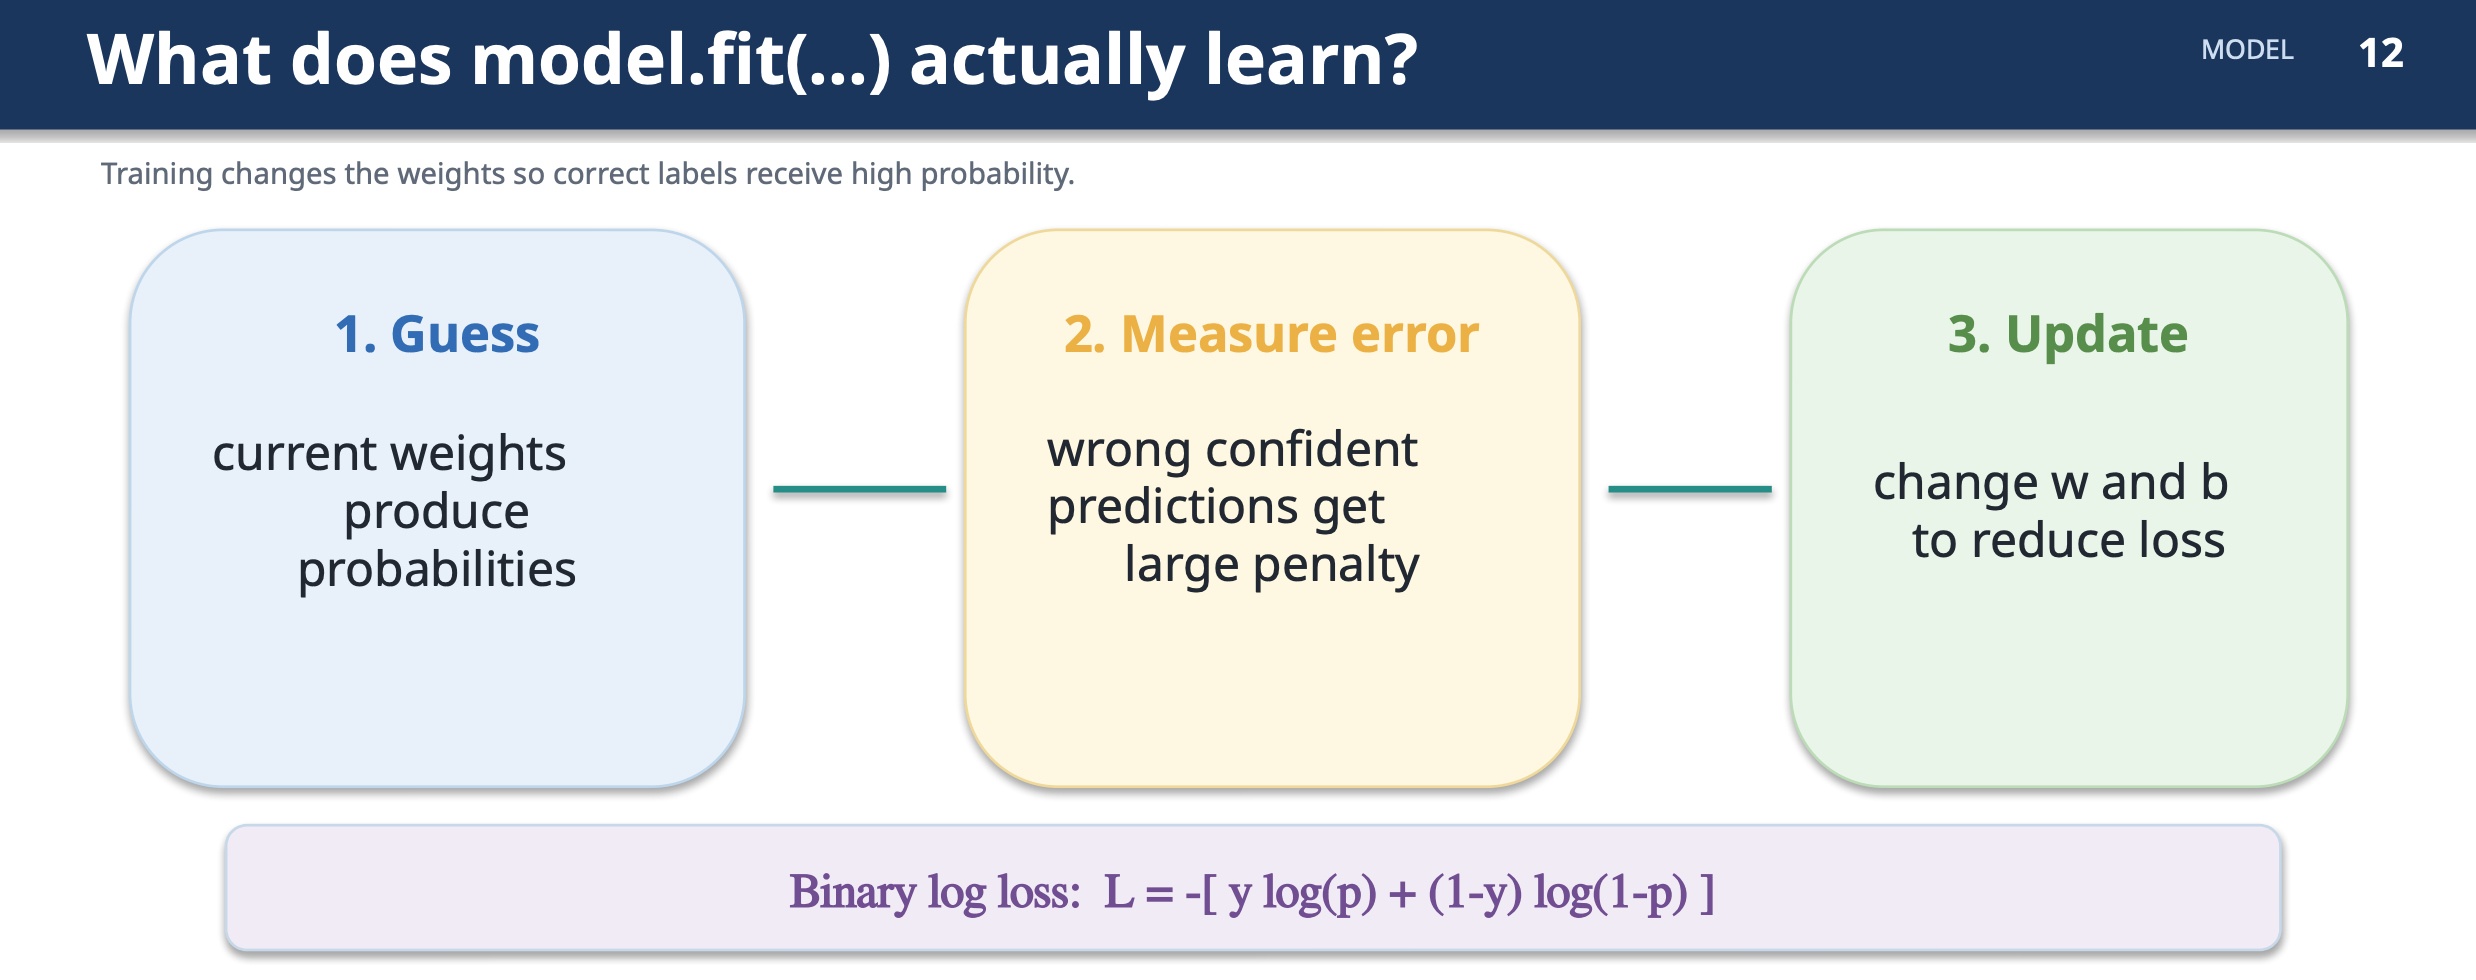

In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# Step 1: split the dataset into training data and unseen test data.
# Step 2: standardise the feature values so different units/scales are comparable.
#
# Scaling formula for one feature:
#       x_scaled = (x - mean_train) / std_train
#
# IMPORTANT:
# We FIT the scaler only on training data.
# We TRANSFORM the test data using the training statistics.
# This avoids leaking information from the test set into training.
# ================================================================

# ↳ Split X and y into training and test subsets.
X_train, X_test, y_train, y_test = train_test_split(
    # ↳ X contains the input measurements; y contains the correct labels.
    X, y,
    # ↳ Reserve 20% of the examples for testing; the remaining 80% are used for training.
    test_size=0.2,
    # ↳ Fix the random split so repeated runs produce the same train/test partition.
    random_state=42
)

# ↳ Create a StandardScaler object.
# It will learn one mean and one standard deviation for each feature.
scaler = StandardScaler()

# ↳ FIT the scaler on X_train, then immediately transform X_train.
# The scaler learns training-set statistics here.
X_train = scaler.fit_transform(X_train)

# ↳ Transform X_test using ONLY the statistics learned from X_train.
# We deliberately do NOT fit the scaler again on the test set.
X_test = scaler.transform(X_test)


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We verify the shape of the training feature matrix after the split and scaling.
# With an 80/20 split of 569 examples, X_train contains 455 patients.
# ================================================================

# ↳ Display the number of training examples and the number of features per example.
# Expected output: (455, 30).
X_train.shape


(455, 30)

## Part-1 : Classification using Logistic Regression ##

### Logistic Regression — the maths hiding behind `model.fit()`

For one patient with feature vector $x=[x_1,\ldots,x_{30}]$:

1. **Weighted score**
   $$z=w^Tx+b=w_1x_1+w_2x_2+\cdots+w_{30}x_{30}+b$$

2. **Convert score to class-1 probability**
   $$p=P(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}}$$

3. **Default decision rule**
   $$p\ge 0.5 \Rightarrow \hat y=1,\qquad p<0.5 \Rightarrow \hat y=0$$

4. **Binary log-loss for one example**
   $$L=-\left[y\log(p)+(1-y)\log(1-p)\right]$$

   This comes from the Bernoulli likelihood
   $$P(y\mid x)=p^y(1-p)^{1-y}$$
   by taking the logarithm and negating it so that optimisation becomes a minimisation problem.

5. **Meaning in this dataset**: class 0 = malignant, class 1 = benign.


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We create and train a Logistic Regression binary classifier.
#
# For one patient vector x, logistic regression first computes:
#       z = w^T x + b
#
# It then converts that score into a probability using the sigmoid:
#       p(y=1|x) = sigmoid(z) = 1 / (1 + e^(-z))
#
# A default threshold of 0.5 converts the probability into class 0 or class 1.
# During model.fit(...), scikit-learn learns the weights w and bias b
# by minimising logistic/log loss on the training examples.
# ================================================================

# ↳ Import the LogisticRegression classifier from scikit-learn.
from sklearn.linear_model import LogisticRegression

# ↳ Create a Logistic Regression model.
# max_iter=1000 allows the numerical optimiser up to 1000 iterations to converge.
model = LogisticRegression(max_iter=1000)

# ↳ Train/f fit the model using the scaled training features and known training labels.
# Conceptually, this learns the weights w and bias b that make correct labels likely.
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# The model has already learned from X_train and y_train.
# We now apply that learned decision rule to the unseen test patients.
# ================================================================

# ↳ Predict one class label (0 or 1) for every row in X_test.
# The result is stored in y_pred for later comparison with the true y_test labels.
y_pred = model.predict(X_test)


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We display the model's predicted labels.
# These are predictions only; they are not yet an accuracy score.
# ================================================================

# ↳ Display the array of predicted class IDs for all test patients.
# Each value is either 0 (malignant) or 1 (benign).
y_pred


array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

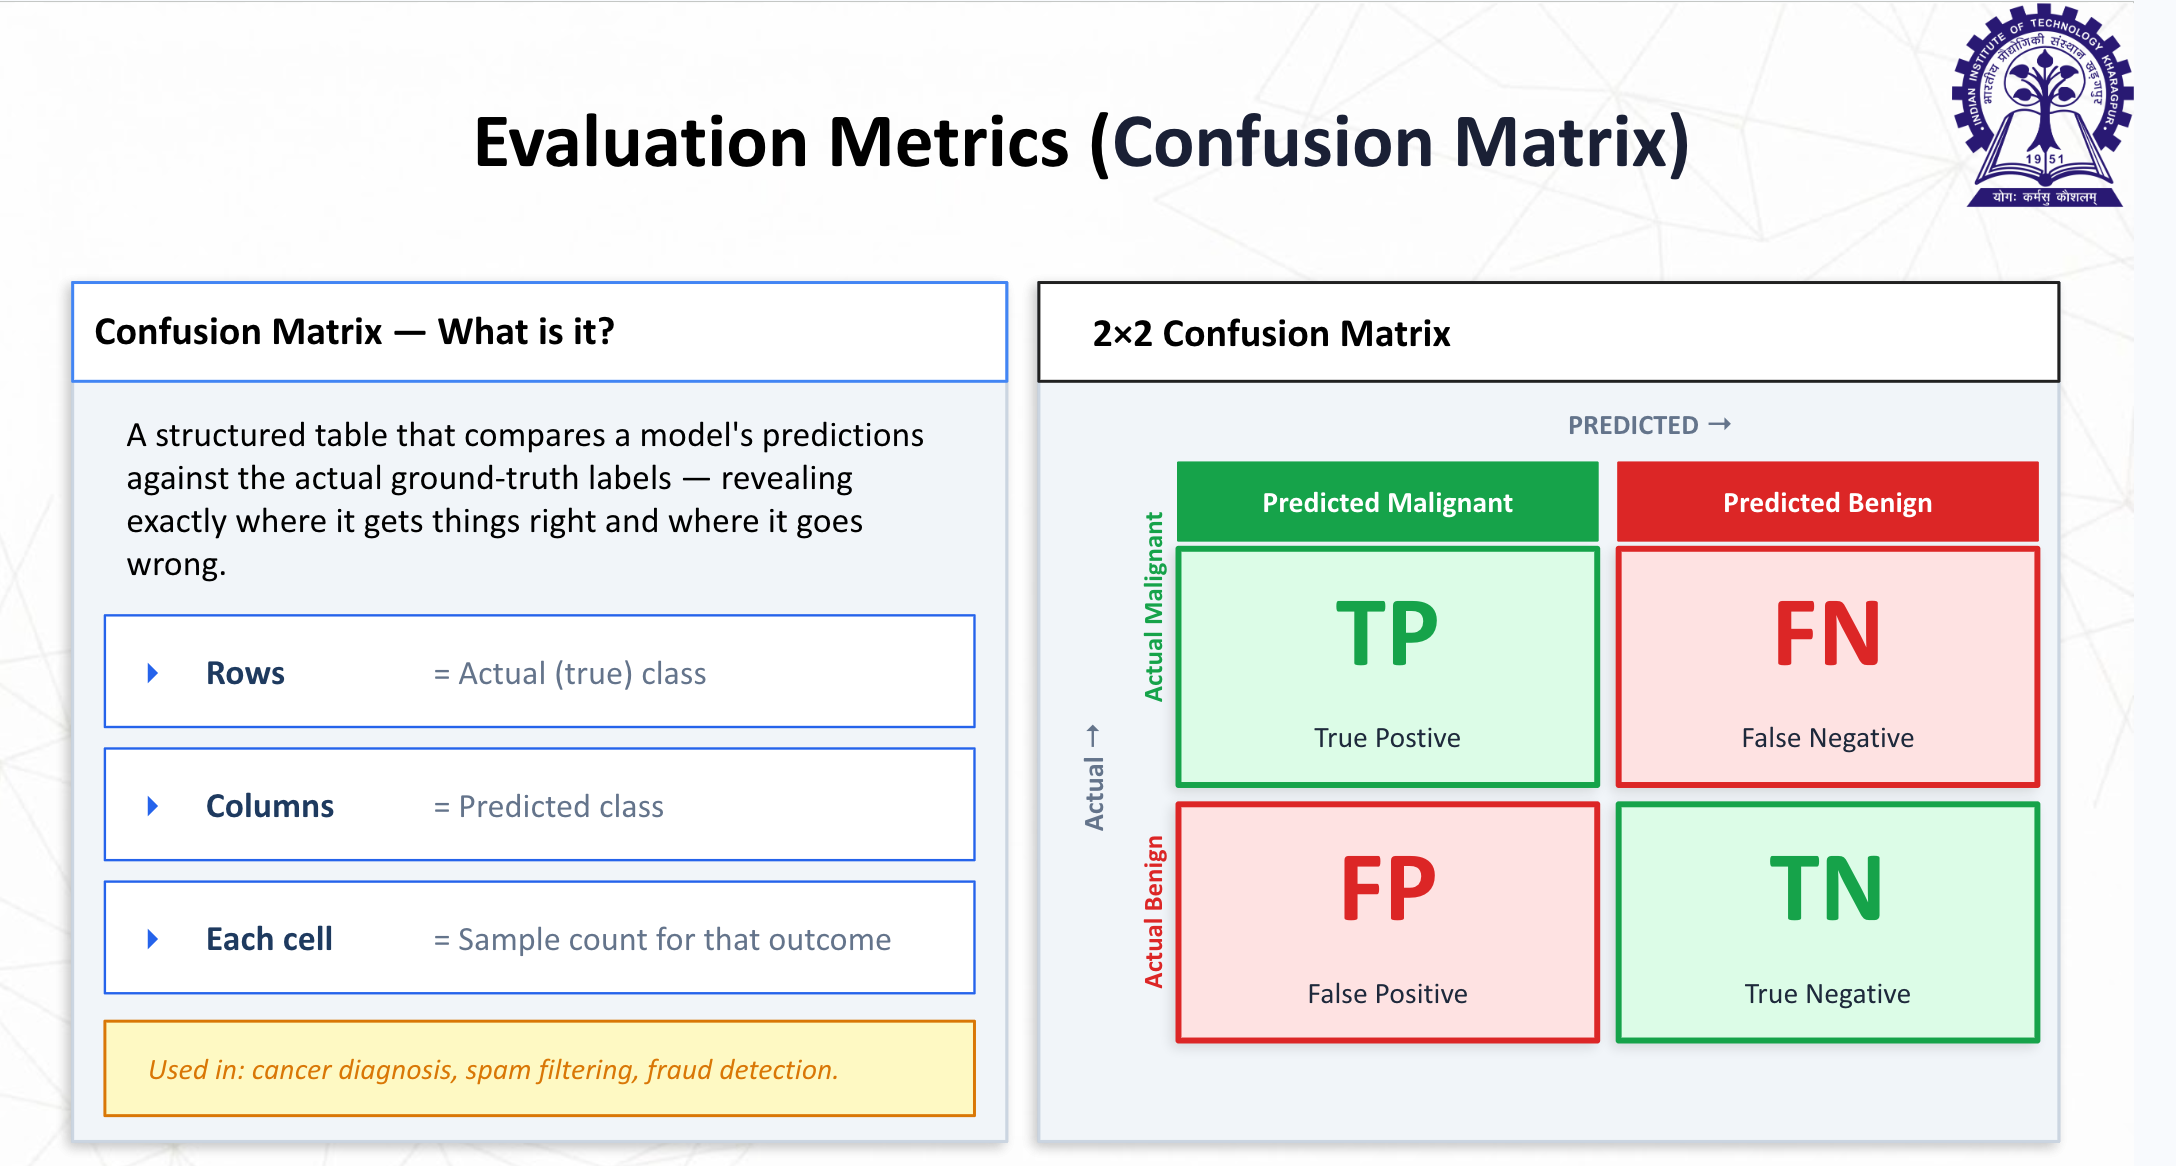

### How to read the evaluation metrics

- **Accuracy**: $\frac{\text{number correct}}{\text{number of test examples}}$
- **Precision for a class**: $\frac{TP}{TP+FP}$ — when the model predicts this class, how often is it correct?
- **Recall for a class**: $\frac{TP}{TP+FN}$ — of all true examples of this class, how many did the model find?
- **F1 score**: $\frac{2PR}{P+R}$ — balances precision and recall.

For a scikit-learn confusion matrix, **rows are true labels and columns are predicted labels**.
Because this dataset defines class 0 as malignant and class 1 as benign, read the matrix using those class names rather than assuming that class 1 means the medically important 'positive' case.


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# We evaluate how well the classifier performed on unseen test data.
#
# We compute:
#   Accuracy  = correct predictions / all test predictions
#   Confusion matrix = counts of each true/predicted class combination
#   Precision = TP / (TP + FP)
#   Recall    = TP / (TP + FN)
#   F1        = 2 * Precision * Recall / (Precision + Recall)
#
# scikit-learn reports these metrics separately for each class.
# ================================================================

# ↳ Import three evaluation utilities from scikit-learn.
# accuracy_score gives overall correctness,
# confusion_matrix shows the error pattern,
# classification_report gives precision, recall, F1 and support.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ↳ Compare y_test (truth) with y_pred (model decisions) and print the overall accuracy.
print("Accuracy:", accuracy_score(y_test, y_pred))

# ↳ Print a heading before the confusion matrix so the output is easy to read.
print("\nConfusion Matrix:")

# ↳ Compute and print the confusion matrix.
# Rows correspond to TRUE labels and columns correspond to PREDICTED labels.
# In this notebook the observed matrix is [[41, 2], [1, 70]].
print(confusion_matrix(y_test, y_pred))

# ↳ Print a heading before the detailed classification metrics.
print("\nClassification Report:")

# ↳ Print class-wise precision, recall, F1-score and support.
# This tells us more than accuracy because it distinguishes different error types.
print(classification_report(y_test, y_pred))


Accuracy: 0.9736842105263158

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Do-It-Yourself (DIY)

**Instructor/learner note:** From this point onward, the notebook intentionally leaves model implementations incomplete.
The cells still explain **what should be done**, but the solution code is not filled in so learners can practise.

So far, we explored Logistic Regression. It assumes a linear decision boundary and relatively simple relationships.
Real-world data can be non-linear, noisy and complex, which motivates trying other classifiers.


## Part - 2 (DIY) ##

Lets explore how we can implement the other ML Classification algorithms, namely

  1. K-Nearest Neighbors - https://scikit-learn.org/stable/modules/neighbors.html
  2. Decision Tree Classifier - https://scikit-learn.org/stable/modules/tree.html
  3. Support Vector Machines - https://scikit-learn.org/stable/modules/svm.html




## Part - 2a : KNN ##

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# This section is intentionally a learner exercise.
# The task is to import and initialise a K-Nearest Neighbours classifier.
# No solution is inserted here so the learner still completes the DIY.
# ================================================================

# ↳ TODO: Import the KNN classifier from scikit-learn.
# TODO: Import KNN

# ↳ TODO: Replace None with an initialised KNN classifier.
knn = None  # TODO: Initialize model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Train the KNN model on the training data.
# The learner should call the appropriate training method here.
# ================================================================

# ↳ TODO: Train the model using the prepared training features and labels.
# TODO: Train model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Use the trained KNN model to predict the test set and evaluate it.
# Compare its behaviour with the Logistic Regression baseline.
# ================================================================

# ↳ TODO: Predict and evaluate.
# TODO: Predict and evaluate


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================


## Part - 2b : Decision Tree Classifier ##

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Import and initialise a Decision Tree classifier.
# The implementation is intentionally left to the learner.
# ================================================================

# ↳ TODO: Import DecisionTreeClassifier from scikit-learn.
# TODO: Import Decision Tree

# ↳ TODO: Replace None with an initialised Decision Tree classifier.
dt = None  # TODO: Initialize model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Train the Decision Tree using the training examples.
# ================================================================

# ↳ TODO: Fit the tree to the training data.
# TODO: Train model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Predict test labels with the trained Decision Tree and evaluate them.
# ================================================================

# ↳ TODO: Predict and evaluate.
# TODO: Predict and evaluate


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================


## Part - 2c : SVM ##

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Import and initialise a Support Vector Machine classifier.
# The learner completes the implementation.
# ================================================================

# ↳ TODO: Import the required SVM classifier.
# TODO: Import SVM

# ↳ TODO: Replace None with an initialised SVM classifier.
svm = None  # TODO: Initialize model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Train the SVM using the training examples.
# ================================================================

# ↳ TODO: Fit the SVM to the training data.
# TODO: Train model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Predict test labels with the trained SVM and evaluate the result.
# ================================================================

# ↳ TODO: Predict and evaluate.
# TODO: Predict and evaluate


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================


## Part-3 : Lets explore a new dataset ##

So, till now we have explored only Binary Classification datasets (breast cancer dataset) but there might be more than two-classes (multiclass datasets).



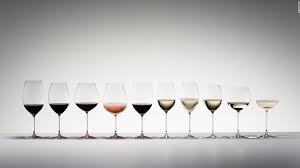

The wine classification problem involves predicting the type of wine based on its chemical properties. Each wine sample is represented by features such as alcohol content, acidity, magnesium, and color intensity, which capture the underlying composition of the wine. The goal is to classify each sample into one of three categories corresponding to different cultivars (wine classes). This is a multi-class classification problem, where a machine learning model learns patterns in the chemical features to accurately distinguish between the different types of wine. Such tasks are common in quality control and can assist in automated decision-making in the food and beverage industry.

## Loading the wine quality data from sklearn datasets ##

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Part 3 switches from binary classification to a multiclass wine dataset.
# The learner should load the wine dataset here.
# ================================================================

# ↳ TODO: Load the dataset that will be used for multiclass classification.
# Load the data


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Split the multiclass wine dataset into training and test portions.
# ================================================================

# ↳ TODO: Create the train/test split.
# Split the data in train and test


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Apply any preprocessing required by the chosen model(s).
# For models that depend on feature scale, standardisation is often useful.
# ================================================================

# ↳ TODO: Add data preprocessing if required.
# Data pre-processing (if required)


## Part - 3a : Logistic Regression (multiclass) ##

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Create a Logistic Regression model for the multiclass wine problem.
# The learner completes the implementation.
# ================================================================

# ↳ TODO: Import Logistic Regression.
# TODO: Import Logistic Regression

# ↳ TODO: Replace None with an initialised multiclass-capable Logistic Regression model.
lg = None  # TODO: Initialize model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Train the multiclass Logistic Regression model.
# ================================================================

# ↳ TODO: Fit the model to the multiclass training data.
# TODO: Train model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Predict and evaluate multiclass Logistic Regression.
# ================================================================

# ↳ TODO: Predict and evaluate.
# TODO: Predict and evaluate


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================


## Part - 3b : KNN Classifier ##

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Create a KNN classifier for the multiclass wine problem.
# ================================================================

# ↳ TODO: Import KNN.
# TODO: Import KNN

# ↳ TODO: Replace None with an initialised KNN classifier.
knn = None  # TODO: Initialize model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Train the KNN model on the multiclass training data.
# ================================================================

# ↳ TODO: Train the model.
# TODO: Train model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Predict wine classes using KNN and evaluate the result.
# ================================================================

# ↳ TODO: Predict and evaluate.
# TODO: Predict and evaluate


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================


## Part - 3c : Decision Tree Classifier ##

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Create a Decision Tree classifier for the multiclass wine task.
# ================================================================

# ↳ TODO: Import DecisionTreeClassifier.
# TODO: Import Decision Tree Classifier

# ↳ TODO: Replace None with an initialised Decision Tree classifier.
dt = None  # TODO: Initialize model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Train the Decision Tree on the multiclass training data.
# ================================================================

# ↳ TODO: Train the model.
# TODO: Train model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Predict wine classes with the Decision Tree and evaluate them.
# ================================================================

# ↳ TODO: Predict and evaluate.
# TODO: Predict and evaluate


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================


## Part - 3d : SVM Classifier ##

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Create an SVM classifier for the multiclass wine problem.
# ================================================================

# ↳ TODO: Import the SVM classifier.
# TODO: Import SVM

# ↳ TODO: Replace None with an initialised SVM classifier.
svm = None  # TODO: Initialize model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Train the SVM on the multiclass training data.
# ================================================================

# ↳ TODO: Train the model.
# TODO: Train model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Predict wine classes with the SVM and evaluate performance.
# ================================================================

# ↳ TODO: Predict and evaluate.
# TODO: Predict and evaluate


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================


## Part 3e: MLP ##

So far, we have explored classical machine learning models on this dataset.
Now, we take a step towards deep learning by implementing a Multi-Layer Perceptron (MLP).

The goal is to understand whether a neural network can capture more complex patterns and improve performance.

In this section, you are encouraged to experiment with key hyperparameters of the MLP classifier, such as the number of hidden layers and neurons (hidden_layer_sizes), the activation function, and the number of training iterations (max_iter). Rather than using fixed values, try different configurations and observe how they impact the models performance. This will help build an intuitive understanding of how neural networks learn and how their behavior changes with different settings.

MLP Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Create a Multi-Layer Perceptron (MLP) neural-network classifier.
# Learners are encouraged to experiment with hidden-layer sizes,
# activation functions and the maximum number of optimisation iterations.
# ================================================================

# ↳ TODO: Import MLPClassifier from scikit-learn.
# TODO: Import MLP

# ↳ TODO: Replace None with an initialised MLP classifier.
mlp = None  # TODO: Initialize model

# ↳ TODO: Experiment with architecture/training hyperparameters and observe their effect.
# TODO: Try experimenting with: hidden_layer_sizes, activation and max_iter


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Train the MLP on the multiclass training data.
# ================================================================

# ↳ TODO: Train the neural-network classifier.
# TODO: Train model


In [ ]:
# ================================================================
# 💬 DIY: WHAT ARE WE DOING IN THIS CELL?
# Use the trained MLP to predict the test set and evaluate its performance.
# ================================================================

# ↳ TODO: Predict and evaluate.
# TODO: Predict and evaluate


In [ ]:
# ================================================================
# 💬 WHAT ARE WE DOING IN THIS CELL?
# This code cell is intentionally blank and is kept as workspace.
# Learners can use it for experiments, checks, or additional code.
# ================================================================
